In [1]:
import pandas as pd

df = pd.read_csv(r'C:\Users\Public\Documents\Axel\wcup26\data\clean_fotmob_match_stats.csv')
df.tail()

,teamId,teamName,matches,total_xG,avg_xG,total_xG_open_play,avg_xG_open_play,total_xG_set_play,avg_xG_set_play,total_xG_non_penalty,...,touches_opp_box,offsides,tackles_won,interceptions,blocks,clearances,keeper_saves,duel_won,yellow_cards,red_cards
43,5902,Qatar,3,1.59,0.530000,1.36,0.453333,0.23,0.076667,1.59,...,25,4,43,25,28,116,12,98,4,2
44,287981,Curacao,3,1.41,0.470000,1.01,0.336667,0.40,0.133333,1.41,...,40,5,50,39,12,74,20,147,7,0
45,7795,Saudi Arabia,3,1.19,0.396667,0.57,0.190000,0.62,0.206667,1.19,...,32,3,55,33,13,103,16,133,6,0
46,6724,Paraguay,4,1.45,0.362500,0.74,0.185000,0.72,0.180000,1.45,...,42,5,103,40,27,160,19,258,9,1
47,6719,Tunisia,3,0.95,0.316667,0.33,0.110000,0.62,0.206667,0.95,...,29,9,56,28,13,71,6,127,1,0


In [2]:
df.columns

Index(['teamId', 'teamName', 'matches', 'total_xG', 'avg_xG',
       'total_xG_open_play', 'avg_xG_open_play', 'total_xG_set_play',
       'avg_xG_set_play', 'total_xG_non_penalty', 'avg_xG_non_penalty',
       'total_xGOT', 'avg_xGOT', 'mean_ball_possession', 'fouls',
       'accurate_passes', 'accurate_long_passes', 'accurate_crosses',
       'ground_duels_won', 'aerial_won', 'dribbles_succeeded', 'goals',
       'big_chances', 'big_chances_missed', 'corners', 'total_shots',
       'shots_off_target', 'shots_on_target', 'blocked_shots', 'hit_woodwork',
       'shots_inside_box', 'shots_outside_box', 'passes', 'own_half_passes',
       'opposition_half_passes', 'throws', 'touches_opp_box', 'offsides',
       'tackles_won', 'interceptions', 'blocks', 'clearances', 'keeper_saves',
       'duel_won', 'yellow_cards', 'red_cards'],
      dtype='str')

In [7]:
# check if 'sho' is in the columns list
x = [col for col in df.columns if 'sho' in col.lower()]
print(f"Columns containing 'sho' (case-insensitive): {x}")

Columns containing 'sho' (case-insensitive): ['total_shots', 'shots_off_target', 'shots_on_target', 'blocked_shots', 'shots_inside_box', 'shots_outside_box']


In [8]:
df[['teamName', 'goals', 'total_shots', 'shots_on_target']].sort_values(by='total_shots', ascending=False).head()

,teamName,goals,total_shots,shots_on_target
6,Germany,11,74,28
1,Belgium,6,73,20
3,Turkiye,3,71,16
2,Canada,9,70,28
0,Brazil,9,60,26


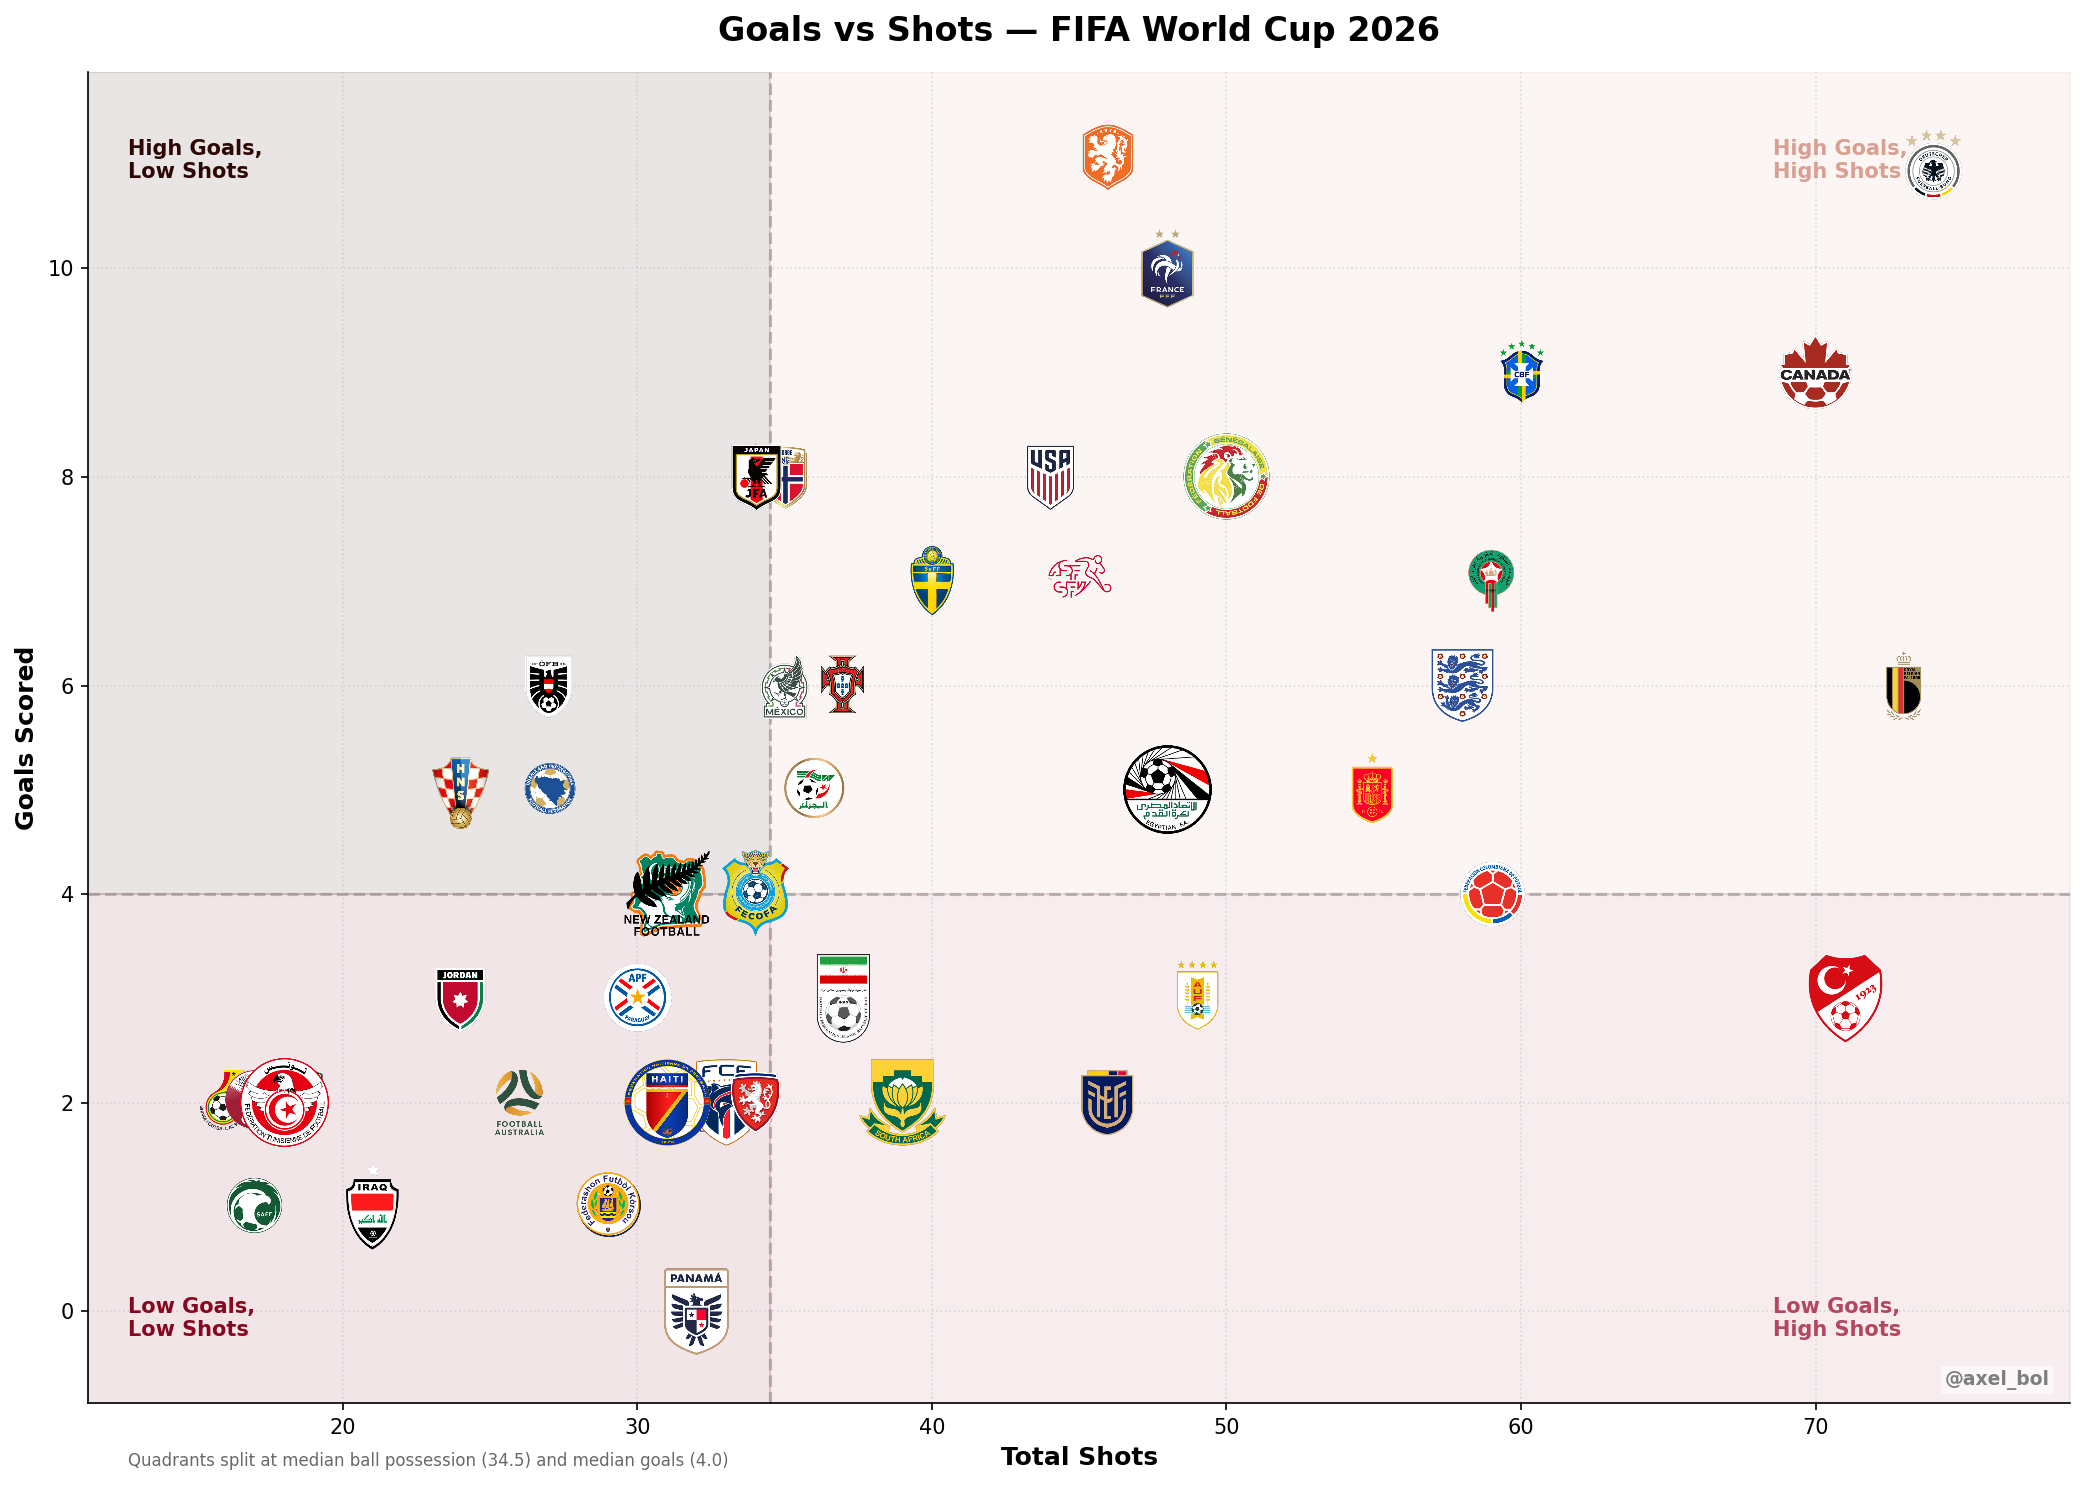

In [12]:
# total shots vs goals

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image
import numpy as np
import os

# --- Config ---
logo_folder = r"C:\Users\Public\Documents\Axel\wcup26\team_logos"
LOGO_CANVAS = 250      # px, square canvas every logo gets normalized into
logo_zoom = 0.17       # now consistent across all logos since canvas size is fixed
annotation_size = 10
fig, ax = plt.subplots(figsize=(14, 10), dpi=150)

x = df['total_shots']
y = df['goals']
pad_x = (x.max() - x.min()) * 0.08
pad_y = (y.max() - y.min()) * 0.08
x_min, x_max = x.min() - pad_x, x.max() + pad_x
y_min, y_max = y.min() - pad_y, y.max() + pad_y

median_shots = x.median()
median_goals = y.median()
ax.axvline(median_shots, linestyle='--', color='gray', linewidth=1.5, alpha=0.5, zorder=1)
ax.axhline(median_goals, linestyle='--', color='gray', linewidth=1.5, alpha=0.5, zorder=1)

_logo_cache = {}

def get_logo(team_id, zoom=logo_zoom, canvas=LOGO_CANVAS):
    """Load a logo and paste it, aspect-ratio preserved, centered on a
    fixed-size transparent square canvas so every logo renders at the
    same visual size regardless of its native resolution/aspect ratio."""
    if team_id in _logo_cache:
        img_array = _logo_cache[team_id]
    else:
        path = os.path.join(logo_folder, f"{team_id}.png")
        img = Image.open(path).convert("RGBA")

        # Scale logo to fit inside the canvas while keeping aspect ratio
        scale = min(canvas / img.width, canvas / img.height)
        new_w, new_h = int(img.width * scale), int(img.height * scale)
        img_resized = img.resize((new_w, new_h), Image.LANCZOS)

        # Paste centered on transparent square canvas
        bg = Image.new("RGBA", (canvas, canvas), (0, 0, 0, 0))
        offset = ((canvas - new_w) // 2, (canvas - new_h) // 2)
        bg.paste(img_resized, offset, img_resized)

        img_array = np.array(bg)
        _logo_cache[team_id] = img_array

    return OffsetImage(img_array, zoom=zoom)

for _, row in df.iterrows():
    try:
        ab = AnnotationBbox(
            get_logo(row['teamId']),
            (row['total_shots'], row['goals']),
            frameon=False,
            zorder=3
        )
        ax.add_artist(ab)
    except FileNotFoundError:
        ax.scatter(row['total_shots'], row['goals'], color='green', s=20, zorder=3)
        ax.annotate(row['teamName'], (row['total_shots'], row['goals']), fontsize=6)

ax.fill_between([x_min, median_shots], median_goals, y_max, color='#2c0703', alpha=0.1, zorder=0)
ax.fill_between([median_shots, x_max], median_goals, y_max, color='#da9f93', alpha=0.1, zorder=0)
ax.fill_between([x_min, median_shots], y_min, median_goals, color='#890620', alpha=0.1, zorder=0)
ax.fill_between([median_shots, x_max], y_min, median_goals, color='#b6465f', alpha=0.1, zorder=0)

x_range = x_max - x_min
y_range = y_max - y_min

annotations = [
    dict(x=x_min + x_range*0.02, y=y_max - y_range*0.05,
         text="High Goals,\nLow Shots", color="#2c0703"),
    dict(x=x_max - x_range*0.15, y=y_max - y_range*0.05,
         text="High Goals,\nHigh Shots", color="#da9f93"),
    dict(x=x_min + x_range*0.02, y=y_min + y_range*0.08,
         text="Low Goals,\nLow Shots", color="#890620"),
    dict(x=x_max - x_range*0.15, y=y_min + y_range*0.08,
         text="Low Goals,\nHigh Shots", color="#b6465f"),
]

for ann in annotations:
    ax.text(ann['x'], ann['y'], ann['text'],
            fontsize=annotation_size, fontweight='bold',
            color=ann['color'], ha='left', va='top', zorder=4)

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_xlabel('Total Shots', fontsize=12, fontweight='bold')
ax.set_ylabel('Goals Scored', fontsize=12, fontweight='bold')
ax.set_title('Goals vs Shots — FIFA World Cup 2026', fontsize=16, fontweight='bold', pad=15)
ax.text(0.02, -0.05, f'Quadrants split at median ball possession ({median_shots:.1f}) and median goals ({median_goals:.1f})',
        transform=ax.transAxes, fontsize=8, va='bottom', color='dimgray',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

# plt.text(8.5, -2, 'Data via Opta | @axel_bol', ha='center', fontsize=8, fontfamily='monospace')
# --- X (Twitter) credit, bottom right ---
ax.text(0.99, 0.01, '@axel_bol', transform=ax.transAxes,
        fontsize=9, fontweight='bold', color='dimgray',
        ha='right', va='bottom', alpha=0.85,
        bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=2))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.savefig(r'C:\Users\Public\Documents\Axel\images\one.png', dpi=300, bbox_inches='tight', pad_inches=0.35)
plt.show()

In [10]:
df[['teamName', 'goals', 'total_shots', 'total_xG']].sort_values(by='goals', ascending=False).head(10)

,teamName,goals,total_shots,total_xG
6,Germany,11,74,8.27
17,Netherlands,11,46,5.48
8,France,10,48,5.87
2,Canada,9,70,8.89
0,Brazil,9,60,9.06
12,Senegal,8,50,5.25
9,Argentina,8,34,5.75
14,USA,8,44,4.63
27,Japan,8,34,4.16
4,Norway,8,35,6.41
